In [1]:
## Supply Chain Forecasting EDA and cleaning

## Supply Chain Forecasting EDA and cleaning

In [2]:
import os
import sys
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.dirname(os.getcwd()))

sns.set_theme(style="whitegrid")


In [3]:
DATA_PATH = os.path.join(tempfile.gettempdir(), "retail_store_inventory.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
df.shape

(73100, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


In [6]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [7]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [8]:
# are there any duplicates in the data?
df.duplicated().sum()

np.int64(0)

In [9]:
df['Date'] = pd.to_datetime(df['Date'], format="%Y-%m-%d")

In [ ]:
# check the categorical variables
cat_cols = ["Category", "Region", "Weather Condition", "Seasonality", "Store ID", "Product ID"]
for col in cat_cols:
    df[col] = df[col].astype("category")


# df['Holiday/Promotion'].dtype


dtype('int64')

In [ ]:
# Outliers detection using IQR method
num_cols = ["Inventory Level", "Units Sold", "Units Ordered", "Price", "Demand Forecast", "Discount", "Competitor Pricing"]

outliers_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    outliers_summary[col] = len(outliers)
print("Outliers detected in each numerical column:")
for col, count in outliers_summary.items():
    print(f"{col}: {count}")

Outliers detected in each numerical column:
Inventory Level: 0
Units Sold: 715
Units Ordered: 0
Price: 0
Demand Forecast: 732
Discount: 0
Competitor Pricing: 0


In [ ]:
# Lower_boundary = Q1 - 1.5 * IQR
# Upper_boundary = Q3 + 1.5 * IQR


# sample_data = [[1, 2, 3, 4, 100]]
# Q1 = np.percentile(sample_data, 25)
# Q3 = np.percentile(sample_data, 75)
# IQR = Q3 - Q1
# Lower_boundary = Q1 - 1.5 * IQR
# Upper_boundary = Q3 + 1.5 * IQR
# print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Lower Boundary: {Lower_boundary}, Upper Boundary: {Upper_boundary}")







Q1: 2.0, Q3: 4.0, IQR: 2.0, Lower Boundary: -1.0, Upper Boundary: 7.0


In [14]:
# EDA - Exploratory Data Analysis
df.groupby("Category")["Demand Forecast"].mean().sort_values(ascending=False)

Category
Furniture      142.824240
Groceries      141.866850
Clothing       141.750079
Toys           141.014558
Electronics    140.001457
Name: Demand Forecast, dtype: float64

<Axes: xlabel='Category'>

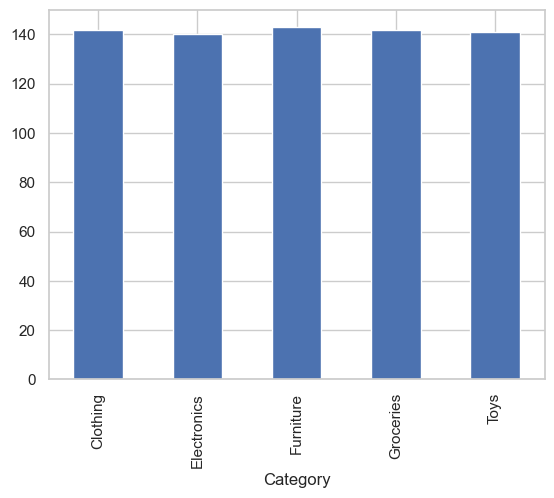

In [16]:
df.groupby("Category")["Demand Forecast"].mean().sort_index().plot(kind="bar")

<Axes: xlabel='Category'>

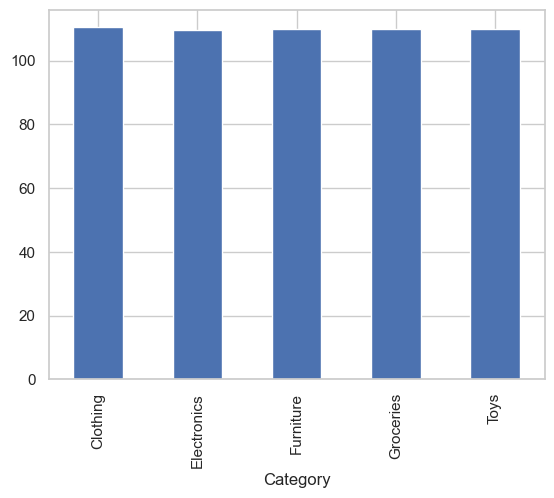

In [19]:
df.groupby("Category")["Units Ordered"].mean().sort_index().plot(kind="bar")

In [20]:
df.groupby(["Region", "Category"])["Demand Forecast"].mean().sort_values(ascending=False)

Region  Category   
South   Clothing       144.969879
        Furniture      144.552864
East    Groceries      144.294267
        Furniture      143.740704
North   Furniture      143.556766
        Electronics    143.520075
West    Clothing       143.173744
South   Groceries      142.426479
North   Toys           141.846154
West    Groceries      141.678267
        Toys           141.124302
East    Toys           140.989006
        Clothing       140.099947
South   Toys           140.078598
East    Electronics    139.764054
West    Furniture      139.462275
North   Groceries      139.034967
South   Electronics    138.792221
North   Clothing       138.682741
West    Electronics    137.961069
Name: Demand Forecast, dtype: float64

<Axes: xlabel='Region'>

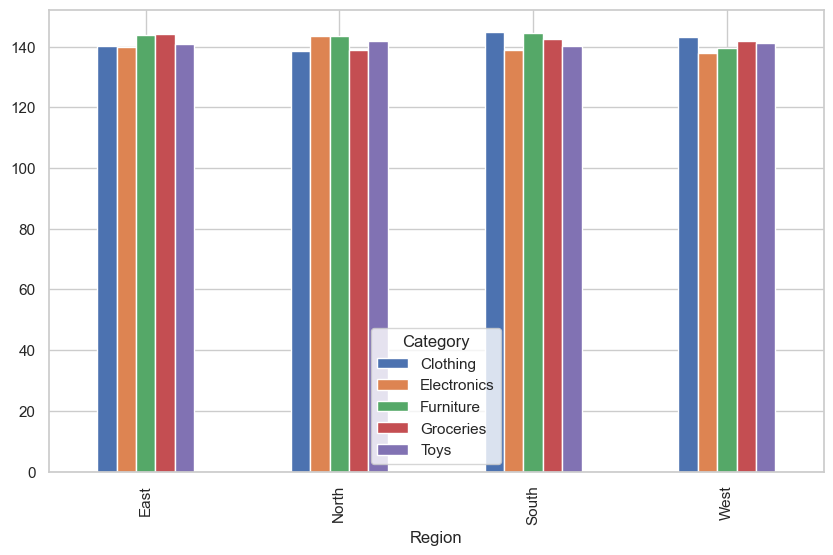

In [21]:
df.groupby(["Region", "Category"])["Demand Forecast"].mean().sort_values(ascending=False).unstack().plot(kind="bar", figsize=(10, 6))

In [ ]:
# we can see that the demand forecast is highest for the Electronics category in the North region, followed by the Clothing category in the South region. The Home & Kitchen category has the lowest demand forecast across all regions.

In [27]:
df[df['Holiday/Promotion'] ==0]['Demand Forecast'].mean().round(2)

np.float64(141.55)

In [28]:
df[df['Holiday/Promotion'] == 1]["Demand Forecast"].mean().round(2)

np.float64(141.44)

In [29]:
df.groupby("Seasonality")["Demand Forecast"].mean().sort_values(ascending=False)

Seasonality
Autumn    142.803401
Winter    141.900097
Spring    140.814250
Summer    140.470029
Name: Demand Forecast, dtype: float64

<Axes: xlabel='Seasonality'>

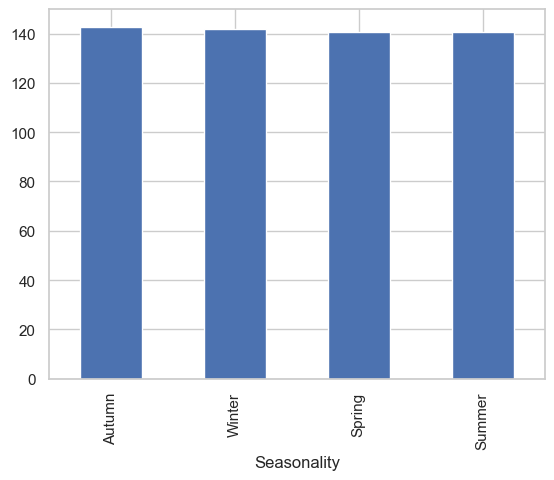

In [30]:
df.groupby("Seasonality")["Demand Forecast"].mean().sort_values(ascending=False).plot(kind="bar")

<Axes: xlabel='Holiday/Promotion'>

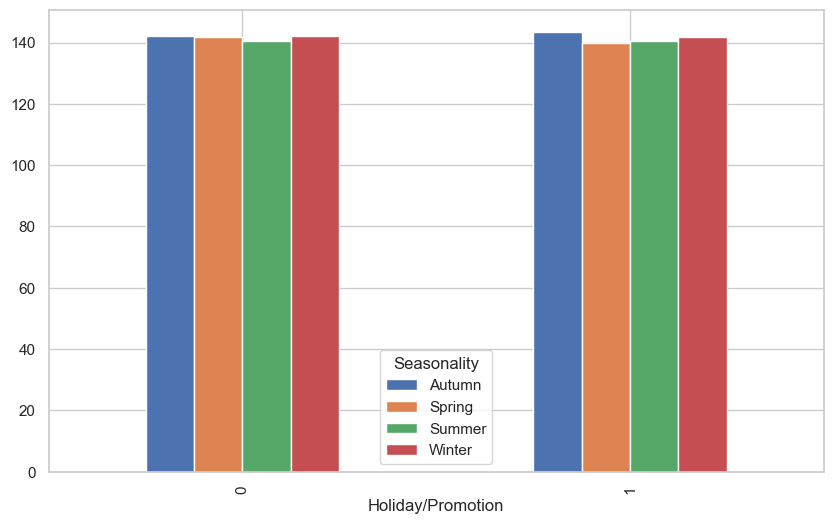

In [31]:
df.groupby(["Holiday/Promotion", "Seasonality"])["Demand Forecast"].mean().unstack().plot(kind="bar", figsize=(10, 6))

In [32]:
df.groupby(["Holiday/Promotion", "Seasonality"])["Demand Forecast"].mean().sort_index()

Holiday/Promotion  Seasonality
0                  Autumn         142.049044
                   Spring         141.764938
                   Summer         140.396363
                   Winter         142.001491
1                  Autumn         143.569206
                   Spring         139.865531
                   Summer         140.544740
                   Winter         141.797059
Name: Demand Forecast, dtype: float64

<Axes: xlabel='Holiday/Promotion,Seasonality,Category'>

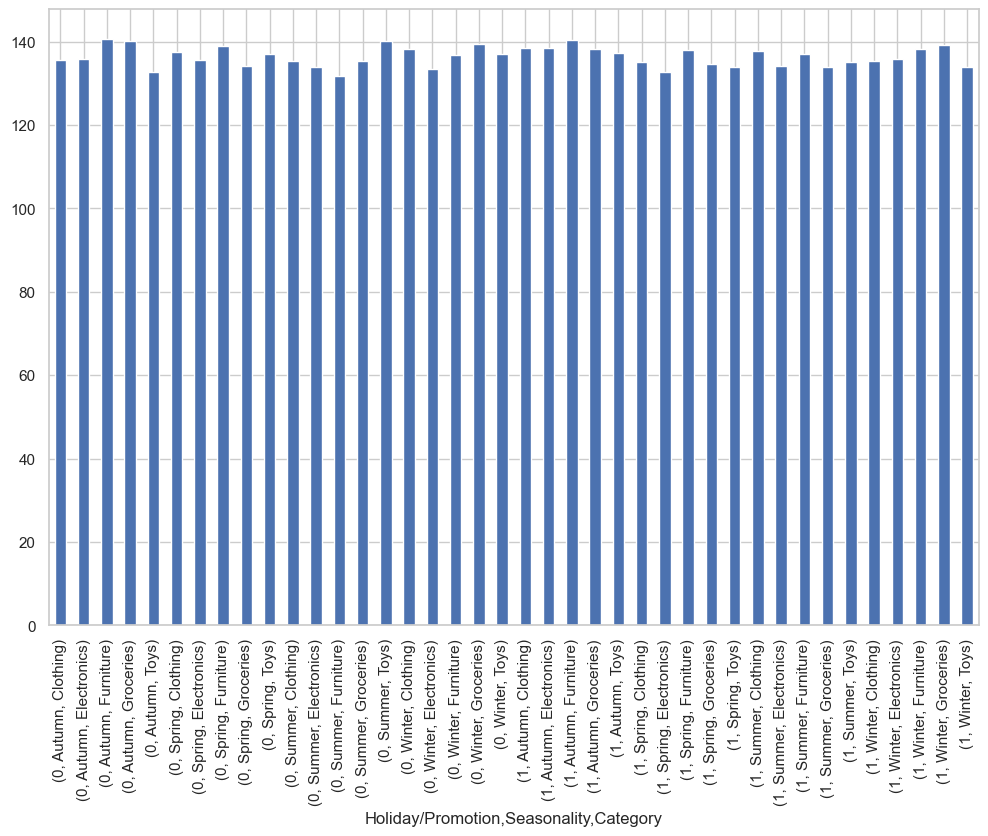

In [35]:
df.groupby(["Holiday/Promotion", "Seasonality", "Category"])["Units Sold"].mean().sort_index().plot(kind="bar", figsize=(12, 8))

In [36]:
corr = df[num_cols].corr()

In [37]:
corr

,Inventory Level,Units Sold,Units Ordered,Price,Demand Forecast,Discount,Competitor Pricing
Inventory Level,1.000000,0.589995,0.001060,0.009140,0.588561,0.004889,0.009365
Units Sold,0.589995,1.000000,-0.000930,0.001082,0.996853,0.002576,0.001259
Units Ordered,0.001060,-0.000930,1.000000,0.004212,-0.001102,-0.000938,0.004596
Price,0.009140,0.001082,0.004212,1.000000,0.000675,0.001509,0.993900
Demand Forecast,0.588561,0.996853,-0.001102,0.000675,1.000000,0.002338,0.000844
Discount,0.004889,0.002576,-0.000938,0.001509,0.002338,1.000000,0.001958
Competitor Pricing,0.009365,0.001259,0.004596,0.993900,0.000844,0.001958,1.000000


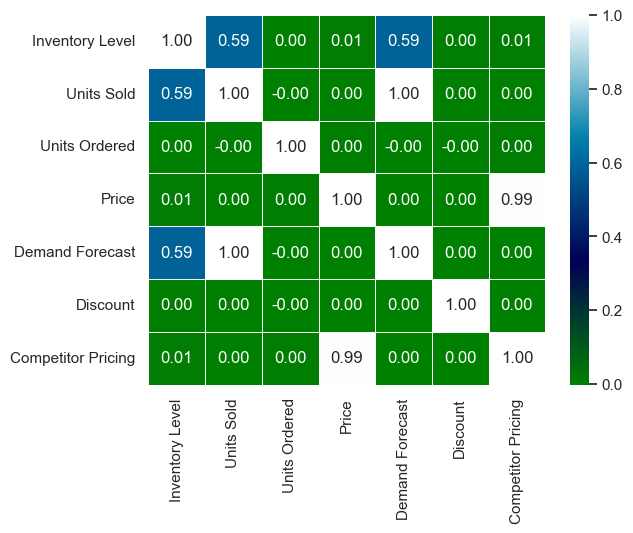

In [ ]:
sns.heatmap(corr, annot=True, cmap="ocean", fmt=".2f", linewidths=0.5)
plt.show()

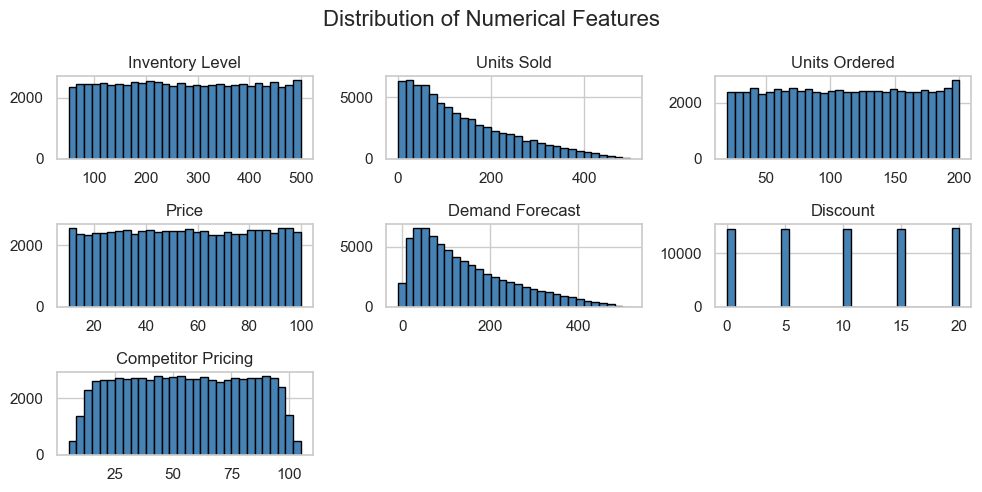

In [45]:
df[num_cols].hist(bins=30, figsize=(10, 5), edgecolor="black", color="steelblue")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\Priya Bhaskar\AppData\Local\Temp\ipykernel_28096\3304087192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Demand Forecast", ax=axes[0], palette="Set2")
C:\Users\Priya Bhaskar\AppData\Local\Temp\ipykernel_28096\3304087192.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="Demand Forecast", ax=axes[1], palette="Set2")


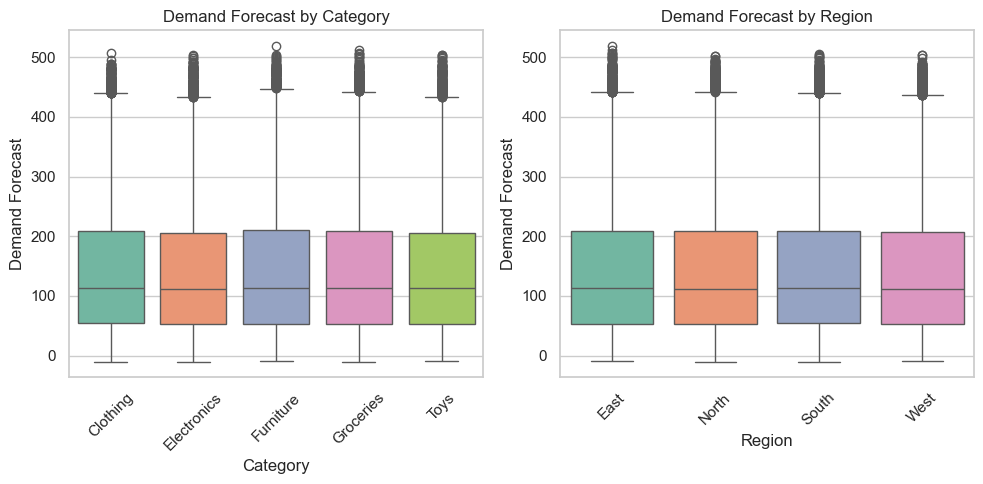

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(data=df, x="Category", y="Demand Forecast", ax=axes[0], palette="Set2")
axes[0].set_title("Demand Forecast by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Demand Forecast")
axes[0].tick_params(axis="x", rotation=45)


sns.boxplot(data=df, x="Region", y="Demand Forecast", ax=axes[1], palette="Set2")
axes[1].set_title("Demand Forecast by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Demand Forecast")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()



In [ ]:
# structure of the box plot:
# 1. minimum value (excluding outliers)
# 2. first quartile (Q1) - 25th percentile
# 3. median (Q2) - 50th percentile
# 4. third quartile (Q3) - 75th percentile
# 5. maximum value (excluding outliers)

# mean, median, mode
# mean ----> average value of a numerical column
# median ----> middle value when the data is sorted
# example: [1, 2, 3, 4, 5] - mean = 3, median = 3
# example: [1, 2, 3, 4, 100] - mean = 22, median = 3 (mean is affected by outliers, while median is not)
# example: [1, 2, 3, 4] - mean = 2.5, median = (2 + 3) / 2 = 2.5 (when there is an even number of values, median is the average of the two middle values)

# what is mode?
# mode ----> most frequently occurring value in a column
# example: [1, 2, 2, 3, 4] -    mode = 2 (because 2 appears twice, while all other values appear once)
# example: [1, 1, 2, 3, 4] -    mode = 1 (because 1 appears twice, while all other values appear once)
# example: [1, 2, 3, 4, 5] -    mode = None (because all values appear once, there is no mode)


In [ ]:
sns.scatterplot(data=df, x="Category", y="Demand Forecast")
plt.show()